In [1]:
import pandas as pd

In [2]:
df_customerdata=pd.read_csv(r"C:\Users\HP\Downloads\DATA ANALYTICS\PYTHON\PROJECT\4453477-Dataset\Dataset\Customer_Master_Data.csv")
df_customerdata.head()

,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
1,CUST10001,Divit Kohli,mkalita@sarin.com,Female,48,Kolkata,Married,0,2023-12-06
2,CUST10002,Kiara Behl,apteanay@hotmail.com,Male,75,Kolkata,Widowed,2,2023-08-23
3,CUST10003,Vaibhav Sankar,bseshadri@choudhry.info,Male,62,Pune,Divorced,2,2022-11-17
4,CUST10004,Shray D’Alia,bdhillon@toor-mall.com,Male,55,Delhi,Divorced,0,2022-12-04


In [3]:
df_transactiondata=pd.read_csv(r"C:\Users\HP\Downloads\DATA ANALYTICS\PYTHON\PROJECT\4453477-Dataset\Dataset\Customer_Transactions.csv")
df_transactiondata.head()

,CustomerID,TransactionDate,TransactionAmount
0,CUST10771,7/31/23,2383.07
1,CUST10100,3/10/24,497.54
2,CUST10031,2/17/25,536.78
3,CUST10987,7/17/23,314.89
4,CUST10831,12/15/24,2543.19


In [4]:
df_customerdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1000 non-null   object
 1   Name           1000 non-null   object
 2   Email          1000 non-null   object
 3   Gender         1000 non-null   object
 4   Age            1000 non-null   int64 
 5   City           1000 non-null   object
 6   MaritalStatus  1000 non-null   object
 7   NumChildren    1000 non-null   int64 
 8   JoinDate       1000 non-null   object
dtypes: int64(2), object(7)
memory usage: 70.4+ KB


In [5]:
df_transactiondata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23050 entries, 0 to 23049
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         23050 non-null  object 
 1   TransactionDate    23050 non-null  object 
 2   TransactionAmount  23050 non-null  float64
dtypes: float64(1), object(2)
memory usage: 540.4+ KB


In [6]:
df_customerdata["JoinDate"]=pd.to_datetime(df_customerdata["JoinDate"],errors="coerce")
df_customerdata["JoinDate"].dtypes

dtype('<M8[ns]')

In [7]:
df_transactiondata["TransactionDate"]=pd.to_datetime(df_transactiondata["TransactionDate"],errors="coerce")
df_transactiondata["TransactionDate"].dtypes

C:\Users\HP\AppData\Local\Temp\ipykernel_20524\4055374925.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_transactiondata["TransactionDate"]=pd.to_datetime(df_transactiondata["TransactionDate"],errors="coerce")


dtype('<M8[ns]')

In [8]:
df_customerdata.isnull().sum()

CustomerID       0
Name             0
Email            0
Gender           0
Age              0
City             0
MaritalStatus    0
NumChildren      0
JoinDate         0
dtype: int64

In [9]:
df_transactiondata.isna().sum()

CustomerID           0
TransactionDate      0
TransactionAmount    0
dtype: int64

In [10]:
print(df_customerdata['CustomerID'].nunique())

1000


In [11]:
print(df_transactiondata['CustomerID'].nunique())

1000


In [12]:
valid_transactions =df_customerdata [
    df_customerdata['CustomerID'].isin(df_transactiondata['CustomerID'])
]

In [13]:
valid_transactions.head()

,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
1,CUST10001,Divit Kohli,mkalita@sarin.com,Female,48,Kolkata,Married,0,2023-12-06
2,CUST10002,Kiara Behl,apteanay@hotmail.com,Male,75,Kolkata,Widowed,2,2023-08-23
3,CUST10003,Vaibhav Sankar,bseshadri@choudhry.info,Male,62,Pune,Divorced,2,2022-11-17
4,CUST10004,Shray D’Alia,bdhillon@toor-mall.com,Male,55,Delhi,Divorced,0,2022-12-04


In [14]:
merged_dataset=pd.merge(df_customerdata,df_transactiondata,on="CustomerID",how="inner")
merged_dataset.head()

,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate,TransactionDate,TransactionAmount
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2022-10-03,961.52
1,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2024-05-31,92.16
2,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2024-05-31,1153.74
3,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2023-01-31,1217.04
4,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2022-06-12,912.08


In [15]:
reference_date = merged_dataset['TransactionDate'].max() + pd.Timedelta(days=1)
reference_date

Timestamp('2025-07-30 00:00:00')

In [16]:
rfm = merged_dataset.groupby('CustomerID').agg({
    'TransactionDate': lambda x: (reference_date - x.max()).days,                          #  Recency
    'CustomerID': 'count',                                                                 # Frequency
    'TransactionAmount': 'sum'                                                             # Monetary
})

In [17]:
rfm

,TransactionDate,CustomerID,TransactionAmount
CustomerID,,,
CUST10000,13,23,21265.49
CUST10001,35,30,28654.31
CUST10002,18,24,23884.03
CUST10003,81,25,24206.03
CUST10004,8,19,25565.30
...,...,...,...
CUST10995,402,21,24325.19
CUST10996,15,21,21809.11
CUST10997,32,20,21120.48


In [18]:
rfm.head()

,TransactionDate,CustomerID,TransactionAmount
CustomerID,,,
CUST10000,13,23,21265.49
CUST10001,35,30,28654.31
CUST10002,18,24,23884.03
CUST10003,81,25,24206.03
CUST10004,8,19,25565.30


In [19]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm

,Recency,Frequency,Monetary
CustomerID,,,
CUST10000,13,23,21265.49
CUST10001,35,30,28654.31
CUST10002,18,24,23884.03
CUST10003,81,25,24206.03
CUST10004,8,19,25565.30
...,...,...,...
CUST10995,402,21,24325.19
CUST10996,15,21,21809.11
CUST10997,32,20,21120.48


In [20]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
CUST10000,13,23,21265.49
CUST10001,35,30,28654.31
CUST10002,18,24,23884.03
CUST10003,81,25,24206.03
CUST10004,8,19,25565.30


In [21]:
rfm["R_score"]=pd.cut(rfm["Recency"].rank(method="first"),5,labels=[1,2,3,4,5])

In [22]:
rfm

,Recency,Frequency,Monetary,R_score
CustomerID,,,,
CUST10000,13,23,21265.49,2
CUST10001,35,30,28654.31,3
CUST10002,18,24,23884.03,2
CUST10003,81,25,24206.03,5
CUST10004,8,19,25565.30,1
...,...,...,...,...
CUST10995,402,21,24325.19,5
CUST10996,15,21,21809.11,2
CUST10997,32,20,21120.48,3


In [23]:
rfm["F_score"]=pd.cut(rfm["Frequency"].rank(method="first"),5,labels=[1,2,3,4,5])
rfm

,Recency,Frequency,Monetary,R_score,F_score
CustomerID,,,,,
CUST10000,13,23,21265.49,2,3
CUST10001,35,30,28654.31,3,5
CUST10002,18,24,23884.03,2,3
CUST10003,81,25,24206.03,5,4
CUST10004,8,19,25565.30,1,1
...,...,...,...,...,...
CUST10995,402,21,24325.19,5,2
CUST10996,15,21,21809.11,2,2
CUST10997,32,20,21120.48,3,2


In [24]:
rfm["M_score"]=pd.cut(rfm["Monetary"].rank(method="first"),5,labels=[1,2,3,4,5])
rfm

,Recency,Frequency,Monetary,R_score,F_score,M_score
CustomerID,,,,,,
CUST10000,13,23,21265.49,2,3,2
CUST10001,35,30,28654.31,3,5,5
CUST10002,18,24,23884.03,2,3,3
CUST10003,81,25,24206.03,5,4,3
CUST10004,8,19,25565.30,1,1,4
...,...,...,...,...,...,...
CUST10995,402,21,24325.19,5,2,3
CUST10996,15,21,21809.11,2,2,3
CUST10997,32,20,21120.48,3,2,2


In [25]:
df_rfm=pd.DataFrame(rfm)

In [26]:
df_rfm

,Recency,Frequency,Monetary,R_score,F_score,M_score
CustomerID,,,,,,
CUST10000,13,23,21265.49,2,3,2
CUST10001,35,30,28654.31,3,5,5
CUST10002,18,24,23884.03,2,3,3
CUST10003,81,25,24206.03,5,4,3
CUST10004,8,19,25565.30,1,1,4
...,...,...,...,...,...,...
CUST10995,402,21,24325.19,5,2,3
CUST10996,15,21,21809.11,2,2,3
CUST10997,32,20,21120.48,3,2,2


In [27]:
df_rfm['R_score'] = df_rfm['R_score'].astype(str)
df_rfm

,Recency,Frequency,Monetary,R_score,F_score,M_score
CustomerID,,,,,,
CUST10000,13,23,21265.49,2,3,2
CUST10001,35,30,28654.31,3,5,5
CUST10002,18,24,23884.03,2,3,3
CUST10003,81,25,24206.03,5,4,3
CUST10004,8,19,25565.30,1,1,4
...,...,...,...,...,...,...
CUST10995,402,21,24325.19,5,2,3
CUST10996,15,21,21809.11,2,2,3
CUST10997,32,20,21120.48,3,2,2


In [28]:
df_rfm['F_score'] = df_rfm['F_score'].astype(str)
df_rfm

,Recency,Frequency,Monetary,R_score,F_score,M_score
CustomerID,,,,,,
CUST10000,13,23,21265.49,2,3,2
CUST10001,35,30,28654.31,3,5,5
CUST10002,18,24,23884.03,2,3,3
CUST10003,81,25,24206.03,5,4,3
CUST10004,8,19,25565.30,1,1,4
...,...,...,...,...,...,...
CUST10995,402,21,24325.19,5,2,3
CUST10996,15,21,21809.11,2,2,3
CUST10997,32,20,21120.48,3,2,2


In [29]:
df_rfm['M_score'] = df_rfm['M_score'].astype(str)
df_rfm

,Recency,Frequency,Monetary,R_score,F_score,M_score
CustomerID,,,,,,
CUST10000,13,23,21265.49,2,3,2
CUST10001,35,30,28654.31,3,5,5
CUST10002,18,24,23884.03,2,3,3
CUST10003,81,25,24206.03,5,4,3
CUST10004,8,19,25565.30,1,1,4
...,...,...,...,...,...,...
CUST10995,402,21,24325.19,5,2,3
CUST10996,15,21,21809.11,2,2,3
CUST10997,32,20,21120.48,3,2,2


In [30]:
df_rfm['RFM_Score'] = df_rfm['R_score'] + df_rfm['F_score'] + df_rfm['M_score']

In [31]:
df_rfm

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,
CUST10000,13,23,21265.49,2,3,2,232
CUST10001,35,30,28654.31,3,5,5,355
CUST10002,18,24,23884.03,2,3,3,233
CUST10003,81,25,24206.03,5,4,3,543
CUST10004,8,19,25565.30,1,1,4,114
...,...,...,...,...,...,...,...
CUST10995,402,21,24325.19,5,2,3,523
CUST10996,15,21,21809.11,2,2,3,223
CUST10997,32,20,21120.48,3,2,2,322


In [32]:
import numpy as np
import pandas as pd

In [33]:
def segment(row):
    if row['RFM_Score'] == '555':
        return 'Champion'
    elif row['R_score'] >= '4' and row['F_score'] >= '4':
        return 'Loyal Customers'
    elif row['R_score'] >= '4':
        return 'Potential Loyalist'
    elif row['R_score'] <= '2' and row['F_score'] >= '3':
        return 'At Risk'
    elif row['RFM_Score'] == '111':
        return 'Lost'
    else:
        return 'Others'

df_rfm['customer_Segment'] = df_rfm.apply(segment, axis=1)

print(df_rfm.head())

            Recency  Frequency  Monetary R_score F_score M_score RFM_Score  \
CustomerID                                                                   
CUST10000        13         23  21265.49       2       3       2       232   
CUST10001        35         30  28654.31       3       5       5       355   
CUST10002        18         24  23884.03       2       3       3       233   
CUST10003        81         25  24206.03       5       4       3       543   
CUST10004         8         19  25565.30       1       1       4       114   

           customer_Segment  
CustomerID                   
CUST10000           At Risk  
CUST10001            Others  
CUST10002           At Risk  
CUST10003   Loyal Customers  
CUST10004            Others  


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
# Customer Segment count
df_rfm

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,customer_Segment
CustomerID,,,,,,,,
CUST10000,13,23,21265.49,2,3,2,232,At Risk
CUST10001,35,30,28654.31,3,5,5,355,Others
CUST10002,18,24,23884.03,2,3,3,233,At Risk
CUST10003,81,25,24206.03,5,4,3,543,Loyal Customers
CUST10004,8,19,25565.30,1,1,4,114,Others
...,...,...,...,...,...,...,...,...
CUST10995,402,21,24325.19,5,2,3,523,Potential Loyalist
CUST10996,15,21,21809.11,2,2,3,223,Others
CUST10997,32,20,21120.48,3,2,2,322,Others


In [46]:
# Customer Segment count
segment_counts=df_rfm['customer_Segment'].value_counts()
segment_counts

customer_Segment
Others                325
Potential Loyalist    255
At Risk               251
Loyal Customers       125
Lost                   24
Champion               20
Name: count, dtype: int64

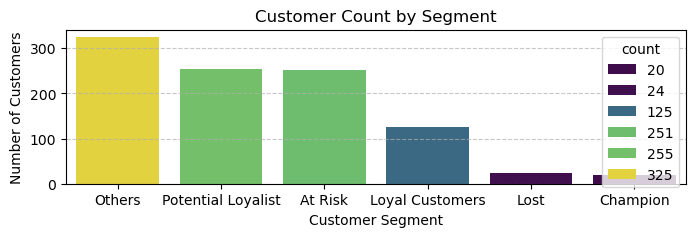

In [47]:
plt.figure(figsize=(8,2))
sns.barplot(x=segment_counts.index, y=segment_counts.values,hue=segment_counts, palette='viridis')
plt.title('Customer Count by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)

In [48]:
# BAR PLOT SUMMERIZATION---->(CUSTOMER SEGMENT COUNT)

# Largest segment: Others (325 customers) — by far the biggest group.
# Mid-sized segments: Potential Loyalist (255) and At Risk (251) — very similar in size.
# Smaller segment: Loyal Customers (125).
# Smallest segments: Lost (24) and Champion (20).

# Key takeaway: Most customers are not yet strongly loyal (large “Others” and "mid-tier" groups), while truly loyal or high-value customers ("Champion", "Loyal") make up a relatively small portion.

In [49]:
# Revenue by segment
revenue_contribution=df_rfm.groupby('customer_Segment')['Monetary'].sum().reset_index()
revenue_contribution

,customer_Segment,Monetary
0,At Risk,6558628.79
1,Champion,622956.28
2,Lost,364220.43
3,Loyal Customers,3309110.69
4,Others,7039571.34
5,Potential Loyalist,5158712.13


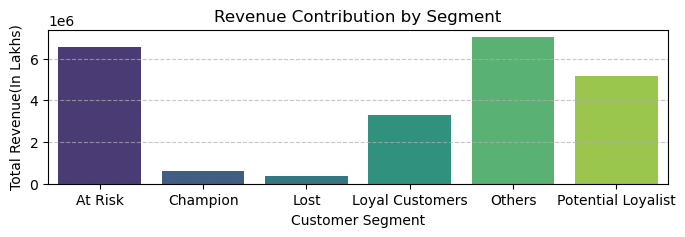

In [50]:
plt.figure(figsize=(8,2))
sns.barplot(x='customer_Segment', y='Monetary', data=revenue_contribution,hue="customer_Segment",palette='viridis')
plt.title('Revenue Contribution by Segment')
plt.ylabel('Total Revenue(In Lakhs)')
plt.xlabel('Customer Segment')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [51]:
# BAR PLOT SUMMERIZATION---->(REVENUE BY SEGMENTS)

# “Others” is the largest contributor, bringing in the highest revenue (around 7M). This suggests a broad, possibly less-defined group is driving a big share of income.
# “At Risk” customers are the second-largest contributor (6.5M). This is critical—losing them would significantly impact revenue, so retention efforts here should be a top priority.
# “Potential Loyalists” (around 5M) and “Loyal Customers” (3.3M) together form a strong base. There’s a clear opportunity to nurture potential loyalists into fully loyal customers to grow stable revenue.
# “Champions” and “Lost” customers contribute very little (<1M each). Champions may be too few (despite high value individually), while lost customers represent already-churned revenue.

# Overall insight: A large portion of revenue comes from customers who are either not fully loyal or are at risk. Focusing on retention and conversion (especially “At Risk” → “Loyal” and “Potential Loyalist” → “Champion”) could significantly strengthen long-term revenue stability.

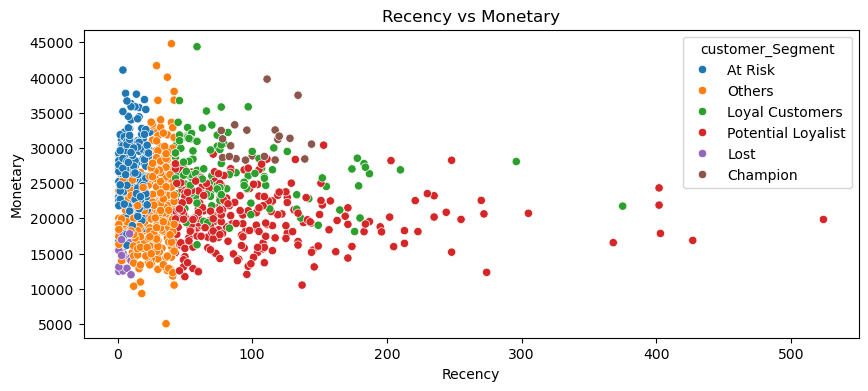

In [52]:
# Scatter plot
plt.figure(figsize=(10,4))
sns.scatterplot(data=df_rfm, x='Recency', y='Monetary', hue='customer_Segment')
plt.title("Recency vs Monetary")
plt.show()

In [53]:
# SCATTER PLOT SUMMERIZATION---->

# 1. Clear inverse pattern---->
#    Customers with low recency (recent buyers) tend to have higher spending.
#    As recency increases (customers haven’t purchased in a while), spending generally declines—though with some variation.

# 2. High-value segments cluster at low recency---->
#    Champions and Loyal Customers are mostly concentrated in:
#    Low recency (0–100 days).
#    High monetary value (25k–40k+).
#    These are the core revenue drivers.

# 3. “Potential Loyalists” show growth opportunity---->
#     Spread across moderate recency (50–250+).
#     Moderate-to-high spending.
#     Indicates customers who could become loyal/champions with engagement.

# 4. “At Risk” customers still have strong value---->
#     Found at low-to-mid recency but relatively high monetary values.
#     These customers used to spend well but may be disengaging.
#     Important group for retention campaigns.

# 5. “Lost” customers are low value--->
#     Clustered at low monetary values (~12k–18k) and low recency spread.
#     Likely not worth heavy investment compared to other segments.

# 6. “Others” dominate the mid-low value range---->
#     Densely packed around low recency but lower monetary (10k–25k).
#     Represents a broad, average customer base.

# 7. outliers---->
#    Some high-recency (300–500+) customers still show moderate spending.
#    These are reactivation opportunities.

# Focus on retention: Champions, Loyal, and At-Risk segments.
# Take care of growth: Potential Loyalists.
# Be selective: Lost customers offer lower Return on Investments(ROI) unless reactivation cost is low.

In [54]:
rfm_sorted = df_rfm.sort_values(by='Monetary', ascending=False)

rfm_sorted['Customer_Revenue'] = rfm_sorted['Monetary'].cumsum()
rfm_sorted['Customer_Percentage'] = rfm_sorted['Customer_Revenue'] / rfm_sorted['Monetary'].sum()

In [55]:
rfm_sorted

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,customer_Segment,Customer_Revenue,Customer_Percentage
CustomerID,,,,,,,,,,
CUST10944,40,31,44784.99,3,5,5,355,Others,44784.99,0.001943
CUST10510,59,30,44367.33,4,5,5,455,Loyal Customers,89152.32,0.003867
CUST10053,29,30,41674.56,3,5,5,355,Others,130826.88,0.005675
CUST10776,4,33,41050.76,1,5,5,155,At Risk,171877.64,0.007456
CUST10696,37,30,40035.48,3,5,5,355,Others,211913.12,0.009192
...,...,...,...,...,...,...,...,...,...,...
CUST10888,42,15,10537.46,3,1,1,311,Others,23017901.89,0.998469
CUST10751,137,15,10536.13,5,1,1,511,Potential Loyalist,23028438.02,0.998926
CUST10973,12,15,10375.62,2,1,1,211,Others,23038813.64,0.999376


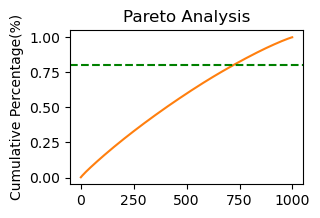

In [58]:
# Pareto analysis
plt.figure(figsize=(3,2))
plt.plot(rfm_sorted['Customer_Percentage'].values,color="C1")
plt.axhline(y=0.8, linestyle='--',color="Green")
plt.title("Pareto Analysis")

plt.ylabel('Cumulative Percentage(%)')
plt.show()

In [ ]:
# CHART ANALYSIS---->(PARETO ANALYSIS)

# The dashed line at 80% shows that roughly 70–75% of the causes contribute to 80% of the total effect.
# This indicates a moderate concentration, not extremely steep.

# The curve rises smoothly rather than sharply.
# This means the impact is spread across many factors, not dominated by just a few important ones.

# There are no single major drivers.
# Multiple factors contributing increasingly.

# Prioritize top contributors first, but,
# Don’t ignore the “middle segment”.
# Improvements should be distributed rather than concentrated.